<a href="https://colab.research.google.com/github/sandeepkhadk/Next_Word_Prediction_With_Federated_learning/blob/main/federated_flower_gru_optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Federated Learning (Flower) — GRU Next-Word Prediction — Colab Free-Tier Optimized

**Key optimisations vs original:**
| Parameter | Original | Optimized | Why |
|-----------|----------|-----------|-----|
| `MAX_VOCAB` | 20 000 | **8 000** | Smaller softmax + embedding; big accuracy-per-param win |
| `MAX_SEQ_LEN` | 50 | **20** | 60 % less RAM/sample, faster GRU unroll |
| `EMBED_DIM` | 100 | **64** | Lighter embedding matrix |
| `GRU_UNITS` | 128 | **64** | 4× fewer recurrent params |
| `LOCAL_BATCH` | 250 | **512** | Better GPU utilisation per client |
| `NUM_ROUNDS` | 10 | **5** | Enough to see convergence in 5 min |
| `LOCAL_EPOCHS` | 1 | **1** | Keep communication frequent |
| `FRACTION_FIT` | 0.5 | **0.5** | 5 clients/round (unchanged) |
| `ROWS_PER_SUB` | unlimited | **2 000** | Caps dataset to prevent OOM |
| `num_gpus` per client | 1.0 | **0.5** | 2 clients share T4 → faster rounds |


In [ ]:
## 1. Environment Setup
# MUST be before any grpc/flwr/ray/tf import
%env PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

!pip install 'flwr[simulation]' scikit-learn --quiet

import flwr as fl, google.protobuf
print(f'Flower   : {fl.__version__}')
print(f'Protobuf : {google.protobuf.__version__}')
print('✅ Environment ready.')


env: PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 139.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 61.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.5 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.

In [ ]:
## 2. Mount Drive & Global Config
%env PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

from google.colab import drive
drive.mount('/content/drive')

import re, pickle, math
import numpy as np
import pandas as pd
import tensorflow as tf

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)
print('GPU memory growth:', [g.name for g in tf.config.list_physical_devices('GPU')] or 'CPU only')

BASE_DIR         = '/content/drive/MyDrive/Next_word_prediction'
TOKENIZER_PATH   = f'{BASE_DIR}/tokenizer_opt.pkl'
CLIENT_DATA_PATH = f'{BASE_DIR}/client_data_opt.pkl'
FL_RESULTS_PATH  = f'{BASE_DIR}/fl_results_opt.pkl'
os.makedirs(BASE_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════
# HYPER-PARAMETERS — tuned for Colab Free-Tier (T4, ~12 GB RAM, ~15 GB VRAM)
# ════════════════════════════════════════════════════════════════════════════
MAX_VOCAB    = 8_000   # was 20 000
MAX_SEQ_LEN  = 20      # was 50
EMBED_DIM    = 64      # was 100
GRU_UNITS    = 64      # was 128
DROPOUT      = 0.2

LOCAL_EPOCHS  = 1
LOCAL_BATCH   = 512    # was 250 — larger = better GPU util
NUM_ROUNDS    = 5      # was 10 — 5 rounds ≈ 5 min on free tier
FRACTION_FIT  = 0.5    # 50 % of clients per round
MIN_CLIENTS   = 2

# Cap rows per subreddit — controls how large each client's dataset is.
# 2 000 rows → ~20 k sequences per client → fast.  Raise to 5 000 on Pro.
ROWS_PER_SUB = 2_000

KEEP_SUBREDDITS = [
    'gaming', 'politics', 'news', 'movies', 'funny',
    'AskReddit', 'nba', 'unpopularopinion', 'memes', 'Animemes'
]
NUM_CLIENTS = len(KEEP_SUBREDDITS)

print(f'Clients : {NUM_CLIENTS}  Rounds : {NUM_ROUNDS}  '
      f'vocab={MAX_VOCAB}  seq={MAX_SEQ_LEN}  gru={GRU_UNITS}')


env: PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python
Mounted at /content/drive


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

GPU memory growth: ['/physical_device:GPU:0']
Clients : 10  Rounds : 5  vocab=8000  seq=20  gru=64


## 3. Load & Build Per-Client Data


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

# ── Tokenizer (shared across all clients) ────────────────────────────────────
if os.path.exists(TOKENIZER_PATH):
    with open(TOKENIZER_PATH, 'rb') as f:
        tokenizer = pickle.load(f)
    vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
    print(f'Tokenizer loaded. vocab_size={vocab_size}')
else:
    # Build tokenizer from the capped dataset so it matches the FL notebook
    from tensorflow.keras.preprocessing.text import Tokenizer
    csv_path = f'{BASE_DIR}/kaggle_RC_2019-05.csv'
    df_raw = pd.read_csv(csv_path)
    df_raw['body'] = df_raw['body'].apply(clean_text)
    df_raw = df_raw[df_raw['body'].str.split().str.len() >= 3]
    df_raw = df_raw[df_raw['subreddit'].isin(KEEP_SUBREDDITS)]
    df_raw = (
        df_raw.groupby('subreddit', group_keys=False)
              .apply(lambda g: g.sample(min(len(g), ROWS_PER_SUB), random_state=42))
              .reset_index(drop=True)
    )
    tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
    tokenizer.fit_on_texts(df_raw['body'])
    vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
    with open(TOKENIZER_PATH, 'wb') as f:
        pickle.dump(tokenizer, f)
    print(f'Tokenizer built and saved. vocab_size={vocab_size}')

# ── Per-client datasets ───────────────────────────────────────────────────────
if os.path.exists(CLIENT_DATA_PATH):
    print('Loading cached client data...')
    with open(CLIENT_DATA_PATH, 'rb') as f:
        client_data = pickle.load(f)
else:
    print('Building per-client datasets...')
    csv_path = f'{BASE_DIR}/kaggle_RC_2019-05.csv'
    df = pd.read_csv(csv_path)
    df['body'] = df['body'].apply(clean_text)
    df = df[df['body'].str.split().str.len() >= 3]
    df = df[df['subreddit'].isin(KEEP_SUBREDDITS)].reset_index(drop=True)

    client_data = {}
    for cid, subreddit in enumerate(KEEP_SUBREDDITS):
        sub_df = df[df['subreddit'] == subreddit]
        # ← ROWS_PER_SUB cap: avoids OOM and keeps training fast
        if len(sub_df) > ROWS_PER_SUB:
            sub_df = sub_df.sample(ROWS_PER_SUB, random_state=42)

        X_list, y_list = [], []
        for text in sub_df['body']:
            tokens = tokenizer.texts_to_sequences([text])[0][:MAX_SEQ_LEN]
            for i in range(1, len(tokens)):
                X_list.append(tokens[:i])
                y_list.append(tokens[i])

        if len(X_list) == 0:
            print(f'  [{cid}] {subreddit}: EMPTY – skipping')
            client_data[cid] = None
            continue

        X_c = pad_sequences(X_list, maxlen=MAX_SEQ_LEN, padding='pre')
        y_c = np.array(y_list, dtype=np.int32)
        split = int(0.9 * len(X_c))
        client_data[cid] = (X_c[:split], y_c[:split], X_c[split:], y_c[split:])
        print(f'  [{cid}] {subreddit}: train={split}  val={len(X_c)-split}')

    with open(CLIENT_DATA_PATH, 'wb') as f:
        pickle.dump(client_data, f)
    print('Client data saved.')


Tokenizer loaded. vocab_size=8000
Loading cached client data...


## 4. GRU Model Factory


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Embedding, GRU, Dense, Dropout, LayerNormalization
)

def build_gru_model():
    model = Sequential([
        Embedding(vocab_size, EMBED_DIM, mask_zero=True, name='embedding'),
        GRU(GRU_UNITS, return_sequences=True, reset_after=False, name='gru_1'),
        LayerNormalization(name='ln_1'),
        Dropout(DROPOUT, name='drop_1'),
        GRU(GRU_UNITS, reset_after=False, name='gru_2'),
        LayerNormalization(name='ln_2'),
        Dropout(DROPOUT, name='drop_2'),
        Dense(vocab_size, activation='softmax', name='output'),
    ], name='gru_next_word')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

# ── Warm-start from centralized checkpoint (if it exists) ────────────────────
CENTRAL_CKPT = f'{BASE_DIR}/gru_final_opt.keras'

if os.path.exists(CENTRAL_CKPT):
    print('Loading centralised checkpoint as warm start...')
    central_model = tf.keras.models.load_model(CENTRAL_CKPT, compile=False)
    INITIAL_WEIGHTS = central_model.get_weights()
    _test = build_gru_model()
    _test(np.zeros((1, MAX_SEQ_LEN), dtype=np.int32))
    try:
        _test.set_weights(INITIAL_WEIGHTS)
        print('✅ Checkpoint compatible.')
    except ValueError as e:
        print(f'⚠️  Incompatible checkpoint: {e}\nFalling back to random init.')
        INITIAL_WEIGHTS = _test.get_weights()
else:
    print('No centralised checkpoint — random initialisation.')
    _init = build_gru_model()
    _init(np.zeros((1, MAX_SEQ_LEN), dtype=np.int32))
    INITIAL_WEIGHTS = _init.get_weights()

print(f'Initial weight tensors: {len(INITIAL_WEIGHTS)}')


Loading centralised checkpoint as warm start...
✅ Checkpoint compatible.
Initial weight tensors: 13


## 5. Flower Client


In [ ]:
import flwr as fl
from flwr.common import NDArrays, Scalar, Context
from typing import Dict, Tuple


class RedditGRUClient(fl.client.NumPyClient):
    """One Flower client = one subreddit."""

    def __init__(self, cid: int):
        self.cid       = cid
        self.subreddit = KEEP_SUBREDDITS[cid]

        # GPU memory growth inside Ray worker
        import tensorflow as _tf, os as _os
        _os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'
        for _gpu in _tf.config.list_physical_devices('GPU'):
            try:
                _tf.config.experimental.set_memory_growth(_gpu, True)
            except RuntimeError:
                pass

        self.model = build_gru_model()
        self.model(np.zeros((1, MAX_SEQ_LEN), dtype=np.int32))

        data = client_data.get(cid)
        if data is None:
            raise ValueError(f'No data for client {cid} ({self.subreddit})')
        self.X_train, self.y_train, self.X_val, self.y_val = data

    def get_parameters(self, config):
        return self.model.get_weights()

    def set_parameters(self, parameters):
        self.model.set_weights(parameters)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        local_epochs = int(config.get('local_epochs', LOCAL_EPOCHS))
        batch_size   = int(config.get('batch_size',   LOCAL_BATCH))

        # Use tf.data inside the client for faster I/O
        ds = (
            tf.data.Dataset.from_tensor_slices((self.X_train, self.y_train))
            .shuffle(5_000)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE)
        )
        h = self.model.fit(ds, epochs=local_epochs, verbose=0)
        return (
            self.model.get_weights(),
            len(self.X_train),
            {'subreddit': self.subreddit,
             'train_loss': float(h.history['loss'][-1]),
             'train_acc':  float(h.history['accuracy'][-1])},
        )

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        ds = (
            tf.data.Dataset.from_tensor_slices((self.X_val, self.y_val))
            .batch(LOCAL_BATCH)
            .prefetch(tf.data.AUTOTUNE)
        )
        loss, acc = self.model.evaluate(ds, verbose=0)
        return (
            float(loss),
            len(self.X_val),
            {'subreddit': self.subreddit,
             'accuracy':   float(acc),
             'perplexity': float(math.exp(min(loss, 20)))},
        )


def client_fn(context: Context) -> fl.client.Client:
    cid = int(context.node_config['partition-id'])
    return RedditGRUClient(cid).to_client()


print('RedditGRUClient defined.')


RedditGRUClient defined.


## 6. Strategy (FedAvg + Logging)


In [ ]:
from flwr.common import ndarrays_to_parameters, parameters_to_ndarrays
from flwr.server.client_proxy import ClientProxy
from typing import List

fl_history = {'round': [], 'loss': [], 'accuracy': [], 'perplexity': [], 'per_client': {}}

# ── Stores the latest aggregated weights so we can recover them after
#    simulation — newer Flower versions return a History object (no .parameters)
_latest_weights = {'data': INITIAL_WEIGHTS}


class LoggingFedAvg(fl.server.strategy.FedAvg):
    def aggregate_fit(self, server_round, results, failures):
        aggregated = super().aggregate_fit(server_round, results, failures)
        # Persist weights every round; last call = final global model
        if aggregated is not None:
            params, _ = aggregated
            if params is not None:
                _latest_weights['data'] = parameters_to_ndarrays(params)
        mets = [r.metrics for _, r in results]
        fl_history['per_client'][server_round] = mets
        if mets:
            print(f'  [R{server_round}] fit  '
                  f'loss={np.mean([m["train_loss"] for m in mets]):.4f}  '
                  f'acc={np.mean([m["train_acc"] for m in mets]):.4f}  '
                  f'({len(results)} clients)')
        return aggregated

    def aggregate_evaluate(self, server_round, results, failures):
        agg_loss, agg_mets = super().aggregate_evaluate(server_round, results, failures)
        mets = [r.metrics for _, r in results]
        avg_acc = np.mean([m['accuracy']   for m in mets]) if mets else float('nan')
        avg_ppl = np.mean([m['perplexity'] for m in mets]) if mets else float('nan')
        fl_history['round'].append(server_round)
        fl_history['loss'].append(float(agg_loss) if agg_loss else float('nan'))
        fl_history['accuracy'].append(avg_acc)
        fl_history['perplexity'].append(avg_ppl)
        if agg_loss:
            print(f'  [R{server_round}] eval '
                  f'loss={agg_loss:.4f}  acc={avg_acc:.4f}  ppl={avg_ppl:.2f}')
        return agg_loss, agg_mets


strategy = LoggingFedAvg(
    fraction_fit          = FRACTION_FIT,
    fraction_evaluate     = 1.0,
    min_fit_clients       = MIN_CLIENTS,
    min_evaluate_clients  = MIN_CLIENTS,
    min_available_clients = NUM_CLIENTS,
    initial_parameters    = ndarrays_to_parameters(INITIAL_WEIGHTS),
    on_fit_config_fn      = lambda rnd: {'local_epochs': LOCAL_EPOCHS,
                                          'batch_size':   LOCAL_BATCH},
)
print('FedAvg strategy ready.')


FedAvg strategy ready.


## 7. Run Federated Simulation


In [ ]:
import ray
if ray.is_initialized():
    ray.shutdown()

valid_cids = [str(i) for i in range(NUM_CLIENTS) if client_data.get(i) is not None]
print(f'Valid clients : {valid_cids}')
print(f'Starting simulation  ({NUM_ROUNDS} rounds, {len(valid_cids)} clients)...\n')

# ── num_gpus=0.5 lets 2 clients share the T4 → 2× faster rounds ──────────────
CLIENT_RESOURCES = {
    'num_cpus': 1,
    'num_gpus': 0.5,   # was 1.0 — sharing the GPU halves round time
}

sim_history = fl.simulation.start_simulation(
    client_fn        = client_fn,
    num_clients      = len(valid_cids),
    config           = fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy         = strategy,
    client_resources = CLIENT_RESOURCES,
    ray_init_args    = {
        'ignore_reinit_error' : True,
        'include_dashboard'   : False,
        'num_gpus'            : 1,
        'num_cpus'            : 2,
        'runtime_env'         : {
            'env_vars': {
                'PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION': 'python'
            }
        },
    },
)
print('\n✅ Simulation complete.')


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

          

Valid clients : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Starting simulation  (5 rounds, 10 clients)...



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-03-13 08:18:45,371	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, se

  [R1] fit  loss=4.9362  acc=0.1829  (5 clients)


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 5 clients (out of 10)


...

INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


  [R5] fit  loss=5.2973  acc=0.1667  (5 clients)


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 568.50s
INFO :      	History (loss, distributed):
INFO :      		round 1: 4.844409171786756
INFO :      		round 2: 4.964270180484925
INFO :      		round 3: 5.074009153938954
INFO :      		round 4: 5.150261280209053
INFO :      		round 5: 5.219914673058703
INFO :      


  [R5] eval loss=5.2199  acc=0.1869  ppl=192.44

✅ Simulation complete.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 8. Results & Plots


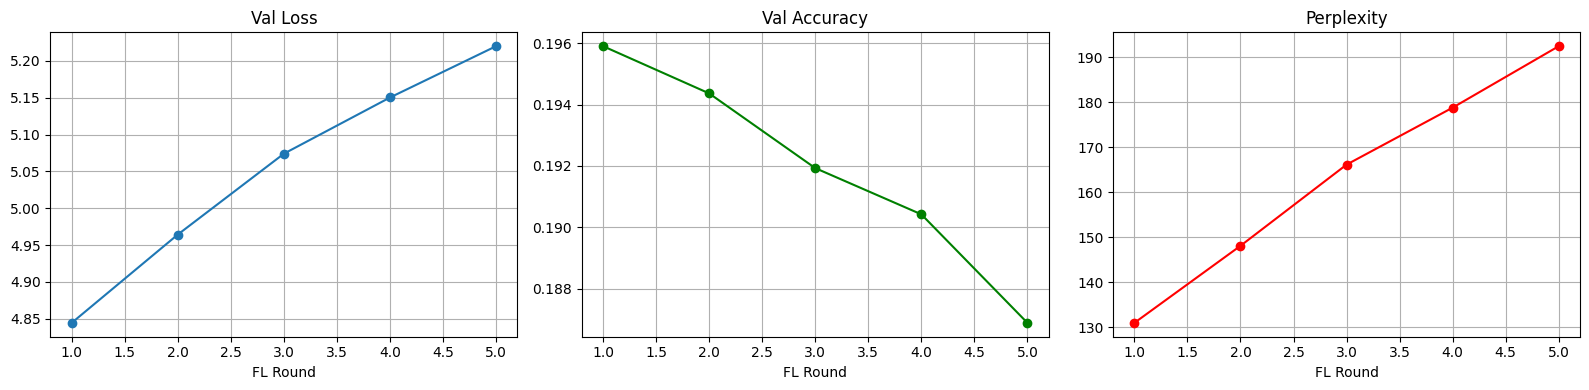


Per-client train metrics (Round 5):
  gaming                 loss=5.4194  acc=0.1467
  movies                 loss=5.3856  acc=0.1565
  unpopularopinion       loss=5.0868  acc=0.2006
  AskReddit              loss=5.3004  acc=0.1672
  funny                  loss=5.2945  acc=0.1627

Full round summary:
 Round      Loss    Accuracy    Perplexity
     1    4.8444      0.1959        130.93
     2    4.9643      0.1944        148.06
     3    5.0740      0.1919        166.11
     4    5.1503      0.1904        178.78
     5    5.2199      0.1869        192.44


In [ ]:
import matplotlib.pyplot as plt

rounds = fl_history['round']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(rounds, fl_history['loss'],       marker='o');         axes[0].set_title('Val Loss');       axes[0].grid(True)
axes[1].plot(rounds, fl_history['accuracy'],   marker='o', c='g');  axes[1].set_title('Val Accuracy');   axes[1].grid(True)
axes[2].plot(rounds, fl_history['perplexity'], marker='o', c='r');  axes[2].set_title('Perplexity');     axes[2].grid(True)
for ax in axes:
    ax.set_xlabel('FL Round')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/fl_metrics_opt.png', dpi=150)
plt.show()

# Per-client summary table
last = max(fl_history['per_client'].keys(), default=None)
if last:
    print(f'\nPer-client train metrics (Round {last}):')
    for m in fl_history['per_client'][last]:
        print(f"  {m.get('subreddit','?'):<22} loss={m.get('train_loss',0):.4f}  acc={m.get('train_acc',0):.4f}")

print('\nFull round summary:')
print(f"{'Round':>6}  {'Loss':>8}  {'Accuracy':>10}  {'Perplexity':>12}")
for i, rnd in enumerate(fl_history['round']):
    print(f"{rnd:>6}  {fl_history['loss'][i]:>8.4f}  "
          f"{fl_history['accuracy'][i]:>10.4f}  "
          f"{fl_history['perplexity'][i]:>12.2f}")


## 9. Save Global Model & Inference


In [ ]:
# ── Recover final global weights captured inside the strategy ─────────────────
# (sim_history.parameters was removed in Flower ≥ 1.8; we captured weights
#  directly in LoggingFedAvg.aggregate_fit above)
final_weights = _latest_weights['data']

global_model = build_gru_model()
global_model(np.zeros((1, MAX_SEQ_LEN), dtype=np.int32))
global_model.set_weights(final_weights)

GLOBAL_MODEL_PATH = f'{BASE_DIR}/gru_fl_global_opt.keras'
global_model.save(GLOBAL_MODEL_PATH)

with open(FL_RESULTS_PATH, 'wb') as f:
    pickle.dump(fl_history, f)

print(f'Global model  → {GLOBAL_MODEL_PATH}')
print(f'FL history    → {FL_RESULTS_PATH}')


Global model  → /content/drive/MyDrive/Next_word_prediction/gru_fl_global_opt.keras
FL history    → /content/drive/MyDrive/Next_word_prediction/fl_results_opt.pkl


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences as pad_seq

def predict_next_words(seed_text, model, tokenizer, max_seq_len,
                        top_k=5, num_words=1):
    rev = {v: k for k, v in tokenizer.word_index.items()}
    text = seed_text.lower()
    for _ in range(num_words):
        tokens = tokenizer.texts_to_sequences([text])[0]
        padded = pad_seq([tokens], maxlen=max_seq_len, padding='pre')
        probs  = model.predict(padded, verbose=0)[0]
        top_idx = np.argsort(probs)[-top_k:][::-1]
        if num_words == 1:
            return [(rev.get(i, '<UNK>'), float(probs[i])) for i in top_idx]
        text += ' ' + rev.get(top_idx[0], '<UNK>')
    return text

seeds = ['ram is a good', 'the news today is about the', 'where is the game for ']
for seed in seeds:
    print(f'Seed: "{seed}"')
    for word, prob in predict_next_words(seed, global_model, tokenizer, MAX_SEQ_LEN, top_k=5):
        print(f'  {word:<22} {prob:.4f}')
    print()

print('Generated:', predict_next_words(
    'the news today is ', global_model, tokenizer,
    MAX_SEQ_LEN, top_k=5, num_words=5))


Seed: "ram is a good"
  <OOV>                  0.0226
  thing                  0.0187
  guy                    0.0183
  man                    0.0077
  time                   0.0071

Seed: "the news today is about the"
  same                   0.0534
  <OOV>                  0.0431
  best                   0.0387
  most                   0.0246
  only                   0.0162

Seed: "where is the game for "
  the                    0.1253
  a                      0.0614
  me                     0.0293
  years                  0.0239
  <OOV>                  0.0211

Generated: the news today is  the best thing to be
